<a href="https://colab.research.google.com/github/liamscanlon5/undergrad_ml_assignments/blob/Assignment02/LiamScanlon02_assignment_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance?
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting?
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

1.   Regression predicts a continuous numerical value (quantity), like the price of a house, while classification predicts a discrete class label (category), like if an email is "Spam" or "Not Spam".

2.   A confusion table/matrix is a table used to evaluate the performance of a classification model by comparing the actual labels against the predicted labels. It helps us understand where the model is getting confused (false positives and false negatives), and it allows us to calculate precision, recall, and F1-score, which provide a deeper look into the model's accuracy.

3. Accuracy is the ratio of **correct predictions / total number of predictions made**. It might not be entirely sufficient if the data is imbalanced. For example, if 99% of the data belongs to Class A, and 1% belongs to Class B, a model that predicts Class A every time will be 99% accurate, but useless at identifying Class B. Also, accuracy treats all errors as equal, but this can be detrimental in certain scenarios when a false negative (missing a disease) is much more dangerous than a false positive.

4. The root mean squared error quantifies the difference between predicted and actual values. It gives a higher weight to large errors because the errors are squared before being averaged.

5. Overfitting is when the model is too complex and learns the training data too well, which results in high accuracy on training data, but poor performance on new data.
Underfitting is when a model is too simple to capture the trend of the data. This results in poor performance on both the training and test data.   

6. This process helps prevent overfitting. By evaluating k on a test set, it allows you to check how the model performs on data it hasn't seen yet. Also, it allows you to find the value of k that balances the bias-variance tradeoff. This ensures the model is complex enough to learn the pattern but simple enough to generalize.

7. A class label as a prediction is simple, clear, and provides an immediate decision for action. However, it loses nuance and doesn't tell you how confident the model is. A probability distribution over class labels provides confidence levels. It allows for flexible decision thresholds, like saying you should only act if probability > 90%. However, it is more complex to interpret and requires an extra step to make a final decision.



**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

Target Label Distribution:
 mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Feature Summary:
           voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000


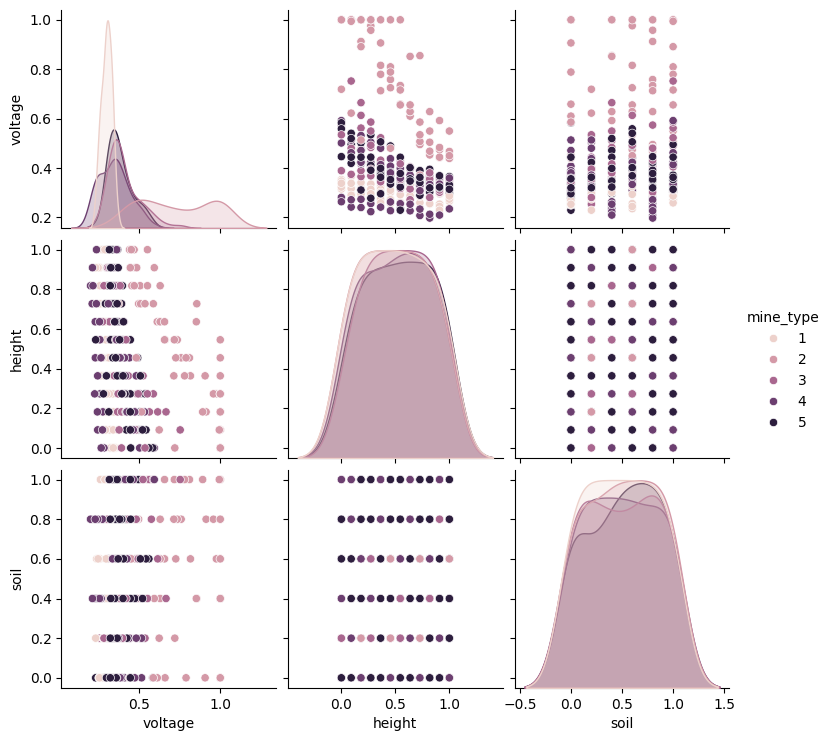

In [34]:
# Q2.1

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('land_mines.csv')

df.head()

# Summary Statistics
print("Target Label Distribution:\n", df['mine_type'].value_counts())
print("\nFeature Summary:\n", df.describe())

# Relationship between features - use pairplots b/c great for seeing how
# features cluster by class
sns.pairplot(df, hue='mine_type')
plt.show()

In [35]:
# Q2.2

from sklearn.model_selection import train_test_split

X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

# Split into 50% training and 50% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

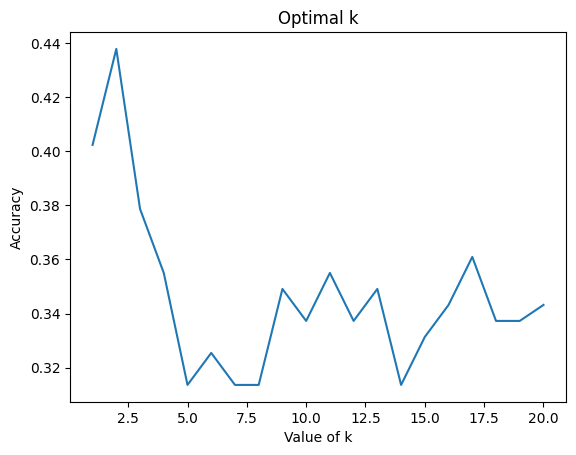

The optimal value for k is: 2


In [36]:
# Q2.3

from sklearn.neighbors import KNeighborsClassifier

accuracies = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracies.append(knn.score(X_test, y_test))

# Plotting the results to find the 'elbow' or peak
plt.plot(k_range, accuracies)
plt.xlabel('Value of k')
plt.ylabel('Accuracy')
plt.title('Optimal k')
plt.show()

# Selecting the best k
best_k = k_range[accuracies.index(max(accuracies))]
print(f"The optimal value for k is: {best_k}")

I determined the optimal k by testing a range of values from 1 to 20 and calculating the accuracy of each on the test set. By plotting these results, I was able to visualize the trade-off between overfitting at low k and underfitting at high k. Finally, I used max(accuracies) to automatically identify and select the specific k value that produced the highest accuracy score.

In [37]:
# Q2.4

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

# Print results
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"\nOverall Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetailed Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[25  0  6  4  1]
 [ 0 32  0  3  0]
 [12  2  9  6  4]
 [12  5  8  8  0]
 [15  2 10  5  0]]

Overall Accuracy: 0.44

Detailed Report:
               precision    recall  f1-score   support

           1       0.39      0.69      0.50        36
           2       0.78      0.91      0.84        35
           3       0.27      0.27      0.27        33
           4       0.31      0.24      0.27        33
           5       0.00      0.00      0.00        32

    accuracy                           0.44       169
   macro avg       0.35      0.42      0.38       169
weighted avg       0.36      0.44      0.39       169



**Q2.4**
An accuracy of 0.44 means that the model's performance is poor overall. It is only getting slightly less than half of the mine types correct. Performance is more accurate for Mine Type 2, with a high recall of 0.91. This means it correctly identified 32/35 actual Type 2 mines. It also has a precision of 0.78, showing that it rarely guesses Type 2 incorrectly. Mine Type 5 is the least accurate, with a recall of 0.00 (none identified correctly). Based on the confusion matrix: [15, 2, 10, 5, 0], the model is misclassifying Type 5 mines as Type 1 mines or Type 3 mines.

**Q2.5**
I'd advise someone to use this predictive model in practice by advising users to investigate any location where the model shows even a low probability of a mine. Also, instead of using the predicted label, I'd advise to use predict_proba, which provides the probability for each possible class label. If the model is even 10% sure a dangerous mine is present, it should be treated as a hazard. Lastly, I'd advise to use the model as a filtering tool to help experts prioritize areas, but it should never be the only reason an area is declared safe without human verification.

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [38]:
# Q3.1

# Load data
df = pd.read_csv('USA_cars_datasets.csv')

# Keep only relevant columns
df = df[['price', 'year', 'mileage']]

# Check for NAs and dimensions
print(f"Dimensions: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}")

# View first few rows
print(df.head())

Dimensions: (2499, 3)
Missing values:
price      0
year       0
mileage    0
dtype: int64
   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654


In [39]:
# Q3.2

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['year', 'mileage']] = scaler.fit_transform(df[['year', 'mileage']])

In [40]:
# Q3.3

X = df[['year', 'mileage']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

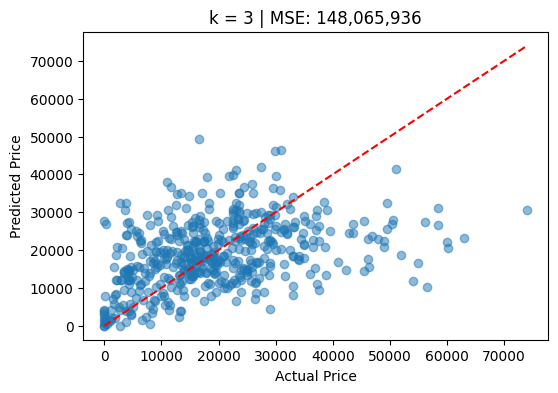

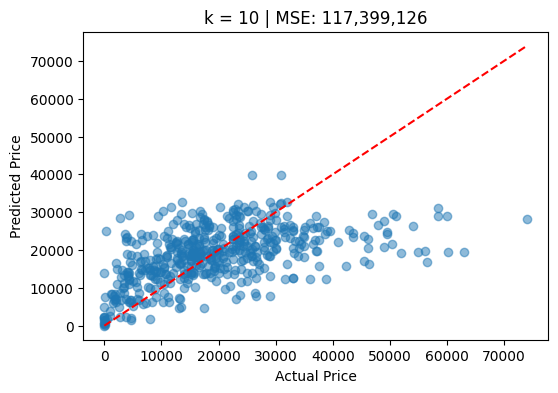

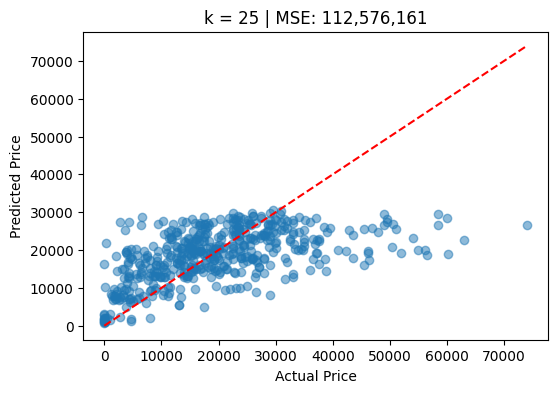

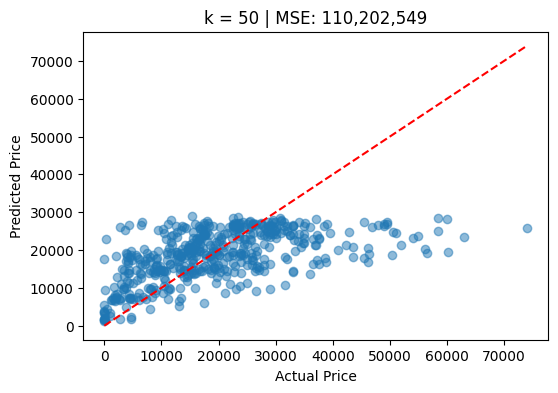

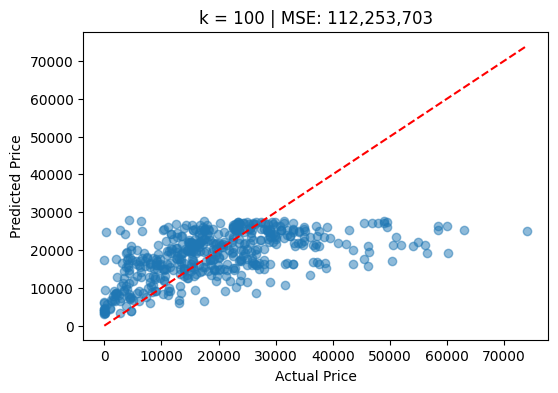

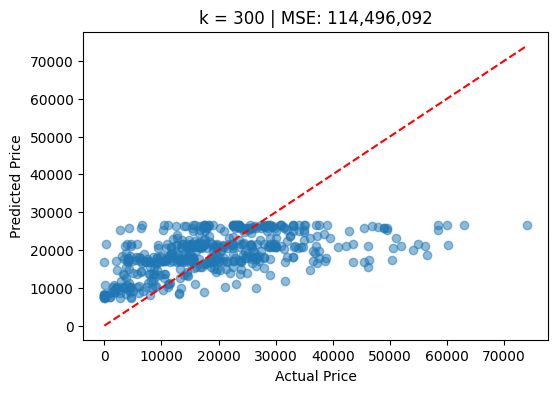

In [41]:
# Q3.4

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

k_values = [3, 10, 25, 50, 100, 300]
mse_results = []

for k in k_values:
    # Build model
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Predict
    y_pred = knn.predict(X_test)

    # Compute MSE
    mse = mean_squared_error(y_test, y_pred)
    mse_results.append(mse)

    # Plot Predicted vs Actual
    plt.figure(figsize=(6,4))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # 45-degree line
    plt.title(f'k = {k} | MSE: {mse:,.0f}')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.show()

In [42]:
# Q3.5

import numpy as np

# Find optimal k
best_k = k_values[np.argmin(mse_results)]
print(f"The optimal k is: {best_k}")

The optimal k is: 50


**Q3.4** As k increases, the vertical spread of the points shrinks and the plot flattens into a horizontal line. All predictions are capped around 30000.

**Q3.6** As you increase k, the points on the scatter plot form a more and more horizontal/flatter plot, capping at a predicted price of 30000. At very low k values, there is a high variance, and the model is sensitive to its immediate neighbors. This captures random price fluctuations rather than true trends, so the scatter plot shows a very loose collection of points. k = 3  has the highest mean squared error because it is chasing individual outliers, which is a sign of overfitting. As k increases, around k = 50, the MSE drops, and the points begin to cluster more tightly. This is the best balance between underfitting and overfitting. At high k's like k = 300, the predicted values flatten out. This is because the model is underfitting and averaging too many cars together. At high k values, the model is too simple to capture the actual relationship between the features and the price.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [43]:
# Q6.1

# Load the data
df = pd.read_csv('airbnb_hw.csv')

# Use .loc to keep only: Review Scores Rating, Price, and Beds
df = df.loc[:, ['Review Scores Rating', 'Price', 'Beds']]


# Remove commas and dollar signs in price column (found error later on, came
# back to fix it)
df['Price'] = df['Price'].replace('[\$,]', '', regex=True).astype(float)

df.head()

<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-1215112469.py:12: SyntaxWarning: invalid escape sequence '\$'
  df['Price'] = df['Price'].replace('[\$,]', '', regex=True).astype(float)


,Review Scores Rating,Price,Beds
0,NaN,145.0,1.0
1,NaN,37.0,1.0
2,NaN,28.0,1.0
3,NaN,199.0,3.0
4,96.0,549.0,3.0


In [44]:
# Q6.2

# Identify rows where Review Scores Rating is null
missing_df = df.loc[df['Review Scores Rating'].isnull()]

# Look at the shape to confirm observations
print(f"Rows to impute: {missing_df.shape[0]}")

Rows to impute: 8323


In [45]:
# Q6.3

# Eliminate any observations with missing values
df_complete = df.dropna(axis=0, how='any')

In [46]:
# Q6.4


# Define features (X) and target (y)
X = df_complete[['Price', 'Beds']]
y = df_complete['Review Scores Rating']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Find k that minimizes SSE
sse_list = []
k_range = range(1, 101)

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    predictions = knn.predict(X_test)

    # SSE = MSE * number of samples
    sse = mean_squared_error(y_test, predictions) * len(y_test)
    sse_list.append(sse)

# Identify the best k
best_k = k_range[np.argmin(sse_list)]
print(f"The optimal k is: {best_k}")

The optimal k is: 88


**Q6.4** To choose the optimal k, you split the complete data into training and test sets, and iterate through a range of k values from 1 to 100. For each value, you calculate the Sum of Squared Errors (SSE) on the test set to measure predictive performance. The k that produces the lowest SSE is selected as the optimal choice because it best balances the model's ability to generalize without overfitting or underfitting.

In [47]:
# Q6.5

# train the final model on the full dataset
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X, y)

# Predict missing ratings
X_missing = missing_df[['Price', 'Beds']].fillna(0)

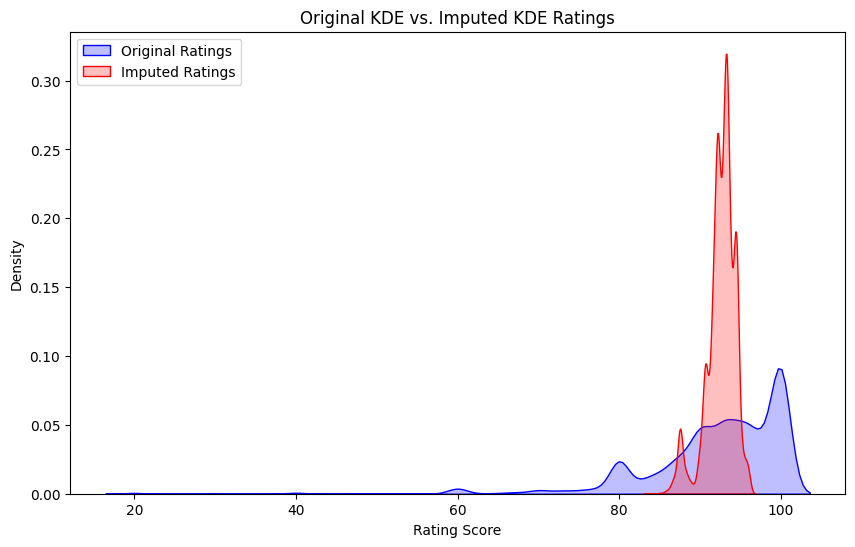

In [48]:
# Q6.6

# create the missing 'imputed_ratings' variable
imputed_ratings = final_model.predict(X_missing)

plt.figure(figsize=(10, 6))
sns.kdeplot(y, label='Original Ratings', color='blue', fill=True)
sns.kdeplot(imputed_ratings, label='Imputed Ratings', color='red', fill=True)
plt.title('Original KDE vs. Imputed KDE Ratings')
plt.xlabel('Rating Score')
plt.legend()
plt.show()

**Q6.6** The imputed ratings have a much narrower and taller peak than the original ratings. This is because by averaging 88 neighbors (based on Q6.4), the algorithm pulls extreme values toward the mean, which results in a distribution with lower variance than real human ratings.